In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from torchvision.datasets import ImageFolder

root_dir = "/Users/lshahsha/Library/CloudStorage/OneDrive-UniversitedeMontreal/3DIEBench"

my_sm_dataset = ImageFolder(
    root = root_dir, 
    transform=None
)


In [ ]:
from torch.utils.data import Dataset
from transformers import AutoImageProcessor
from pathlib import Path
from PIL import Image
import torch

class DIEBenchDataset(Dataset):
    def __init__(self, root, model_name="facebook/dinov2-small"):
        self.processor = AutoImageProcessor.from_pretrained(model_name)
        
        # each object folder is one sample
        # root/synset/obj_id/ → collect all obj_id folders
        self.object_dirs = sorted([
            obj_dir
            for synset_dir in sorted(Path(root).iterdir()) if synset_dir.is_dir()
            for obj_dir in sorted(synset_dir.iterdir()) if obj_dir.is_dir()
        ])

    def __len__(self):
        return len(self.object_dirs)

    def __getitem__(self, idx):
        obj_dir = self.object_dirs[idx]
        
        # load all 50 images in order
        image_paths = sorted(obj_dir.glob("image_*.jpg"))
        images = [Image.open(p).convert("RGB") for p in image_paths]
        
        # processor returns (T, C, H, W)
        pixel_values = self.processor(images=images, return_tensors="pt")["pixel_values"]
        
        return pixel_values
    
root_dir = "/Users/lshahsha/Library/CloudStorage/OneDrive-UniversitedeMontreal/3DIEBench"
mydat = DIEBenchDataset(root_dir, model_name="facebook/dinov2-small")

/Users/lshahsha/Documents/GitHub/model_tutorial/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [12]:
len(mydat)

52472

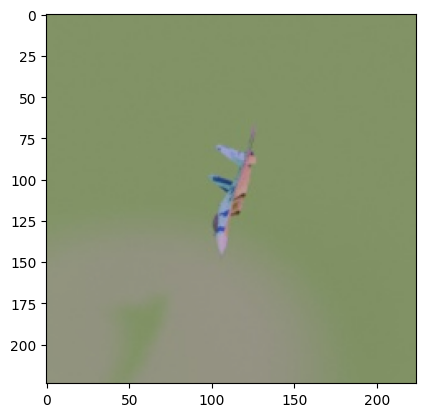

In [ ]:
img = mydat[121][0]          # (C, H, W)
img = img.permute(1, 2, 0)  # → (H, W, C): this is what matplotlib expects

# undo normalization
mean = torch.tensor([0.485, 0.456, 0.406]) # the default normalization
std  = torch.tensor([0.229, 0.224, 0.225])
img  = img * std + mean # undoing

# clip to [0, 1] for matplotlib
img = img.clamp(0, 1)

plt.figure()
plt.imshow(img)
plt.show()

In [21]:
# now let's try and pass this to DataLoader
from torch.utils.data import DataLoader     # Batches + shuffling + iteration over datasets

# # define a collate_fun
# def stack_fn(batch):
#     images = [item[0] for item in batch]   # list of PIL Images
#     labels = torch.tensor([item[1] for item in batch])

#     inputs = processor(
#         images,
#         return_tensors="pt"
#     )

#     return inputs["pixel_values"], labels


myloader = DataLoader(
    mydat,
    batch_size=19,
    shuffle=False,
    sampler=None,
    batch_sampler=None,
    num_workers=0, # for parallel loading?
    # collate_fn=stack_fn, # THIS IS IMPORTANT
    drop_last=False,
    pin_memory=False,
    persistent_workers=False,
)

In [26]:
batch = next(iter(myloader))
batch.shape
# images, labels = batch

# print(type(images))
# print(type(labels))

# for img, label in myloader:
#     print(type(img), label)
#     break


torch.Size([19, 50, 3, 224, 224])

In [30]:
for step, a in enumerate(myloader):
    # immediately break if we reach max_steps
    max_steps = 10
    if step >= max_steps:
        break

    print(a.shape)


torch.Size([19, 50, 3, 224, 224])
torch.Size([19, 50, 3, 224, 224])
torch.Size([19, 50, 3, 224, 224])
torch.Size([19, 50, 3, 224, 224])
torch.Size([19, 50, 3, 224, 224])
torch.Size([19, 50, 3, 224, 224])
torch.Size([19, 50, 3, 224, 224])
torch.Size([19, 50, 3, 224, 224])
torch.Size([19, 50, 3, 224, 224])
torch.Size([19, 50, 3, 224, 224])


In [33]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image


import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, random_split
from torch.utils.data import DataLoader 

from transformers import AutoImageProcessor, AutoModel




# first define the dataset class
# Data needs to be stored in a specific directory structure 
# parent_dir/objects/object_instances/instance_rotations

# the dictionary containing model info
config = {
    "facebook/dinov2-small": {"dim": 384},
    "facebook/dinov2-base":  {"dim": 768},
}


class DIEBenchDataset(Dataset):
    """creates a Dataset class which can later be used with DataLoaders
    It needs two methods: __len__ and __getitem__. This will also automatically
    apply the transformations needed for the model
    <this may change in the future>

    Args:
        root (str): root directory where images are stored
        model_name (str): name of the model to get the preprocessor from transformers package
    """
    def __init__(self, root, model_name="facebook/dinov2-small"):
        # get the default transformations for your desired model variant
        self.processor = AutoImageProcessor.from_pretrained(model_name)
        
        # each object folder is one sample
        # root/synset/obj_id/ → collect all obj_id folders
        # a two-level hierarchy!
        self.object_dirs = sorted([
            obj_dir
            for synset_dir in sorted(Path(root).iterdir()) if synset_dir.is_dir()
            for obj_dir in sorted(synset_dir.iterdir()) if obj_dir.is_dir()
        ])

    def __len__(self):
        return len(self.object_dirs)

    def __getitem__(self, idx):
        obj_dir = self.object_dirs[idx]
        
        # load all 50 images in order
        # note that here, the order is important.
        # get all the images starting with image_
        image_paths = sorted(obj_dir.glob("image_*.jpg"))
        # convert all the images to RGB, ready to be passed on to the processor
        images = [Image.open(p).convert("RGB") for p in image_paths]
        
        # processor returns (T, C, H, W)
        # where T is the sequence length later to be used in the model
        # for this dataset it is 50
        # as there are 50 different views of the object
        pixel_values = self.processor(images=images, return_tensors="pt")["pixel_values"]
        
        return pixel_values
   

class MRSimple(nn.Module):
    def __init__(self, 
                 hidden_dim, 
                 encoder_variant="facebook/dinov2-small", 
                 dropout=0.1, 
                 lstm_num_layers=1):
        super().__init__()

        # this is the size of the internal memory of the lstm
        self.hidden_dim    = hidden_dim
        self.embedding_dim = config[encoder_variant]["dim"]

        # load the pretrained image processor and encoder
        self.encoder_processor = AutoImageProcessor.from_pretrained(encoder_variant)
        self.encoder           = AutoModel.from_pretrained(encoder_variant)
        
        # freeze encoder once at init, not on every forward pass
        self._freeze_encoder()

        # dropout only makes sense with more than one layer
        # the dropout for lstm only works if you have multiple layers
        # with one layer, if you use dropout, it will throw a warning
        lstm_dropout = dropout if lstm_num_layers > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size   = self.embedding_dim, 
            hidden_size  = self.hidden_dim, 
            num_layers   = lstm_num_layers, 
            bias         = True, 
            batch_first  = True, 
            dropout      = lstm_dropout, 
            bidirectional= False, 
        )

        # this is the final linear layer to project back to embedding dim 
        # so you can compare with the "observed" embeddings
        self.fc = nn.Linear(self.hidden_dim, self.embedding_dim, bias=False)

    def _freeze_encoder(self):
        self.encoder.eval()
        for p in self.encoder.parameters():
            p.requires_grad = False

    def forward(self, images):
        # do the necessary preprocessing
        inputs = self.encoder_processor(images=images, return_tensors="pt").to(device)

        # only the encoder is under no_grad, not the lstm
        with torch.no_grad():
            outputs       = self.encoder(**inputs)
            # you can also use the actual outputs and think of a way to summarize them
            # <embeddings = outputs.last_hidden_state[:, 1:, :] >
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # (N*T, embedding_dim)


        print(cls_embeddings.shape)
        # infer n_stimuli and T from the input list directly
        # images is a list of (n_stimuli * T) PIL images
        T        = len(set(metadata["rot_angle_deg"]))   # you can pass T as argument instead
        n_stimuli = cls_embeddings.shape[0] // T

        # reshape to (N, T, embedding_dim)
        out = cls_embeddings.view(n_stimuli, T, self.embedding_dim)

        # lstm runs with gradients
        hidden, (hn, cn) = self.lstm(out)  # hidden: (N, T, hidden_dim)

        # slice before the head — don't predict from the last timestep
        predictions = self.fc(hidden[:, :-1, :])   # (N, T-1, embedding_dim)
        
        # targets are the actual embeddings shifted by one
        targets = out[:, 1:, :].detach()            # (N, T-1, embedding_dim)

        return predictions, targets


def train(root):
    HIDDEN_DIM = 512
    ENCODER_VARIANT = "facebook/dinov2-small"
    LSTM_NUM_LAYERS = 1
    DROPOUT = 0.1
    BATCH_SIZE = 128
    MAX_EPOCH = 1000
    # get the device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # create an isntance of the model
    model = MRSimple(
        hidden_dim      = HIDDEN_DIM, 
        encoder_variant = ENCODER_VARIANT, 
        dropout         = DROPOUT, 
        lstm_num_layers = LSTM_NUM_LAYERS,
    ).to(device)

    # we will do a cross validation style
    # for now, just using one train set and one test set
    # create an instance of the 

    # define the optimizer
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # record loss
    loss_all = []

    # now create the dataset class
    dataset = DIEBenchDataset(root, model_name=ENCODER_VARIANT)

    # now let's divide to train and test sets
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size

    # divide to train and test using random split
    train_set, test_set = random_split(dataset, [train_size, test_size])

    # now make loader objects
    train_loader = DataLoader(
                            train_set,
                            batch_size=BATCH_SIZE,
                            shuffle=False,
                            sampler=None,
                            batch_sampler=None,
                            num_workers=0, # for parallel loading?
                            # collate_fn=stack_fn, # THIS IS IMPORTANT
                            drop_last=False,
                            pin_memory=False,
                            persistent_workers=False,
                        )
    test_loader = DataLoader(
                            test_set,
                            batch_size=BATCH_SIZE,
                            shuffle=False,
                            sampler=None,
                            batch_sampler=None,
                            num_workers=0, # for parallel loading?
                            # collate_fn=stack_fn, # THIS IS IMPORTANT
                            drop_last=False,
                            pin_memory=False,
                            persistent_workers=False,
                        )
    # define an optimizer
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # now training
    loss_all = [] # to store all the loss values
    # put the model in training mode
    model.train()
    for epoch, images in enumerate(train_loader):
        # first make sure images and labels are on the correct device
        images = images.to(device) # Move images to device

        # firsts pass the images to the model we instantiated earlier
        emb_pred, targets = model(images)# Forward pass: compute predicted embeddings

        # loss is defined as the 1 - cosine similarity across the embedding
        current_loss = 1 - F.cosine_similarity(emb_pred, targets, dim = -1).mean()
        # store the current value of loss
        loss_all.append(current_loss.item())


        # clear out the optimizer gradients
        optimizer.zero_grad()

        # backprop
        current_loss.backward()

        # update the parameters
        optimizer.step()

        if epoch % 10 == 0:
            print(f"epoch {epoch} | loss: {current_loss.item():.4f}")

    # once training is done, test:
    # first put the model in eval mode
    model.eval()

    dis_test = []
    for epoch, images in enumerate(test_loader):
        # first make sure images and labels are on the correct device
        images = images.to(device) # Move images to device
        # firsts pass the images to the model we instantiated earlier
        emb_pred_test, targets_test = model(images)# Forward pass: compute predicted embeddings
        # calculate distance 1 - cosine similarity

        # loss is defined as the 1 - cosine similarity across the embedding
        current_dist = 1 - F.cosine_similarity(emb_pred_test, targets_test, dim = -1).mean()

        # record it
        dis_test.append(current_dist.item())

    # printout the final test score?
    print(dis_test.mean())
    return model, loss_all





train(root = root_dir)

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 1015.99it/s, Materializing param=layernorm.weight]                                 


ValueError: Could not make a flat list of images from tensor([[[[[ 0.3994,  0.4166,  0.4166,  ...,  0.4166,  0.4166,  0.4166],
           [ 0.3994,  0.4166,  0.4166,  ...,  0.4166,  0.4166,  0.4166],
           [ 0.4166,  0.4166,  0.4166,  ...,  0.4166,  0.4166,  0.4166],
           ...,
           [ 0.8789,  0.8789,  0.8789,  ...,  0.3994,  0.3994,  0.3994],
           [ 0.8789,  0.8789,  0.8789,  ...,  0.3994,  0.3994,  0.3994],
           [ 0.8789,  0.8789,  0.8789,  ...,  0.3994,  0.3994,  0.3994]],

          [[ 0.3978,  0.4153,  0.4153,  ...,  0.4153,  0.4153,  0.4153],
           [ 0.3978,  0.4153,  0.4153,  ...,  0.4153,  0.4153,  0.4153],
           [ 0.4153,  0.4153,  0.4153,  ...,  0.4153,  0.4153,  0.4153],
           ...,
           [ 0.3803,  0.3803,  0.3803,  ...,  0.3627,  0.3627,  0.3627],
           [ 0.3803,  0.3803,  0.3803,  ...,  0.3627,  0.3627,  0.3627],
           [ 0.3803,  0.3803,  0.3803,  ...,  0.3627,  0.3627,  0.3627]],

          [[-0.0267, -0.0092, -0.0